# Classification Metrics

#### 🎯 Learning Goals

1. Understand the problem of assessing the performance of a classification model.
2. Understand how different metrics can be used to assess the performance of a classification model depending on the business problem.
3. See feature transformation and pipelines in action.

In [1]:
# Load our libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use a nicer style for plots
plt.style.use("seaborn-v0_8-muted")

To make things simpler and focus on the classification metrics, let begin from where we finished in the last notebook..

In [2]:
# Load the loans data
loans = pd.read_csv("data/loan_defaults.csv")

In [3]:
# Drop the rows with missing values
loans.dropna(inplace=True)

# Transform categorical variables to dummies
str_cols = [col for col in loans.columns if loans[col].dtype == "O"]
loans = pd.get_dummies(loans, columns=str_cols, drop_first=True)

In [4]:
# Import sklearn functionalities
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [5]:
# Prepare features and target
X, y = loans.drop(columns=["loan_status"]), loans["loan_status"]

# Split the data into train and test sets so we can evaluate and compare our models
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, 
                                            shuffle=True, random_state=72)

### An Example of Feature Tranformation: Unskewing Features with Yeo–Johnson

 We want to use the bank loan analysis as an opportunity to get to know the [`PowerTransformer`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PowerTransformer.html) class from scikit-learn and apply a Yeo-Johnson transformation to the features.

 Why this step? Many numeric features are skewed (i.e. they have long tails, lots of small values, a few huge ones). Models like logistic regression and Naïve Bayes behave better when features are closer to bell-shaped; otherwise a few extreme values can dominate the fit. We'll use the Yeo–Johnson power transform (via `PowerTransformer`) to unskew each numeric feature and put them on a more comparable scale. Unlike Box–Cox (another often-used transformation method), Yeo–Johnson handles zeros and negative values, so we don’t have to hack the data first. Practical rules: apply it to numeric columns only, fit the transformer on the training set, then use that fitted transformer to transform both train and test—this avoids leaking information from test into training and keeps the evaluation honest. To optimize the workflow for this, we use a functionality called a pipeline (see below).

Let's see the Yeo-Johson transformation in action. But, before, let's not forget to load the packages that we need.


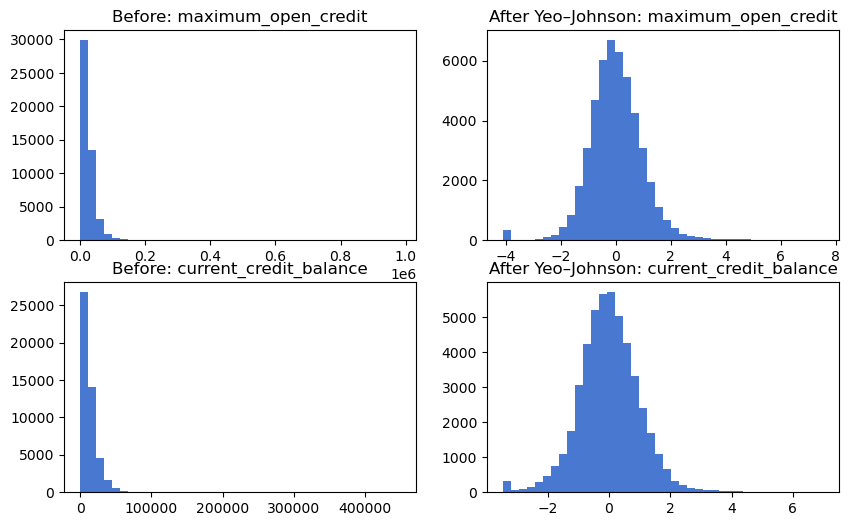

In [6]:
from sklearn.preprocessing import PowerTransformer  # For Yeo-Johnson transformation
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline  # For pipeline
from sklearn.compose import ColumnTransformer, make_column_selector as selector

# Now let's apply Yeo-Johson to a few selected columns and plot the result

# Choose some numeric columns 
plt_cols = ["maximum_open_credit", "current_credit_balance"]

# Fit on TRAIN only!
pt = PowerTransformer(method="yeo-johnson", standardize=True).fit(X_train[plt_cols])
# The .fit() step computes the parameters (lambdas, means, variances) needed for the transformation based on the training data.


# Prepare transformed data (train only)
X_train_yj = pd.DataFrame(pt.transform(X_train[plt_cols]), columns=plt_cols, index=X_train.index)
# .transform() actually applies the learned transformation to the data — it uses the parameters estimated in .fit().
# The result is wrapped back into a pandas DataFrame, preserving the original column names and row indices.


# Plot before/after
fig, axes = plt.subplots(len(plt_cols), 2, figsize=(10, 3*len(plt_cols)))
for r, c in enumerate(plt_cols):
    axes[r, 0].hist(X_train[c].dropna(), bins=40)
    axes[r, 0].set_title(f"Before: {c}")
    axes[r, 1].hist(X_train_yj[c].dropna(), bins=40)
    axes[r, 1].set_title(f"After Yeo–Johnson: {c}")


Here is a heuristic explanation of what the Yeo-Johnson transformation does. We pick a power $\lambda$ that *warps the x-axis* of each numeric feature so the histogram looks more like a single, symmetric hump (bell-shaped) with steadier spread. Intuitively, the transform **stretches** crowded low values and **compresses** long high-value tails (and handles negatives sensibly), while keeping the rank order the same (it’s monotonic). The “fit” step just searches for the $\lambda$ that makes the transformed training data look most normal (think: the bell curve works best for models like Naïve Bayes or logistic regression), then we **freeze that $\lambda$** and apply the same transformation to both train and test.

### Pipelines

Now, we integrate the transformation into a `Pipeline`. See how it works for naïve Bayes.


In [7]:
# Continuous numerics = numeric dtype AND not strictly {0,1}
num_df = X_train.select_dtypes(include=np.number)
is_one_hot = num_df.apply(lambda s: set(pd.unique(s.dropna())) <= {0, 1})
cont_cols = num_df.columns[~is_one_hot]

preprocess = ColumnTransformer(
    [("yeojohnson", PowerTransformer(method="yeo-johnson", standardize=True), cont_cols)],
   force_int_remainder_cols=False   
)

nbc = Pipeline([
    ("prep", preprocess),
    ("clf", GaussianNB())  # clf stands for classifier
]).fit(X_train, y_train)

nbc

Pipeline(steps=[('prep',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   transformers=[('yeojohnson',
                                                  PowerTransformer(),
                                                  Index(['current_loan_amount', 'credit_score', 'years_in_current_job',
       'annual_income', 'monthly_debt', 'years_of_credit_history',
       'months_since_last_delinquent', 'number_of_open_accounts',
       'number_of_credit_problems', 'current_credit_balance',
       'maximum_open_credit', 'bankruptcies', 'tax_liens'],
      dtype='object'))])),
                ('clf', GaussianNB())])

This may look a little weird at first. Generally, a **pipeline** in scikit-learn is a way to chain multiple steps — such as data preprocessing and model training — into a single, streamlined workflow. Each step feeds its output to the next one. When you call `.fit()` on the pipeline, it fits all transformers and the model in sequence using the training data. Later, when you call `.predict()`, the same fitted transformations are applied automatically before making predictions. This ensures consistent, clean, and reproducible processing for both training and test data. And it can safe you many lines of code. Pipelines are thus very convenient, but when using them it is important that you still **always fully understand what you are doing!** Otherwise, you may end up with a pipeline that does something else than what you expected...

Think of a pipeline as a **to-do list** for your data. Each step runs in the order specified by the pipeline. During **fit**, steps that learn parameters (like `PowerTransformer`) do so **from the training data only**; the final step (the classifier) learns weights. During **predict** (see below), every step transforms the input and passes it on to a prediction—there is (and should be) no re-learning.


Now lets look more closely at the above code. When you run:

```python
nbc = Pipeline([
    ("prep", preprocess),
    ("clf", GaussianNB())
]).fit(X_train, y_train)
```

the pipeline is fitted **only on the training data**. Here’s what happens step by step:

1. The pipeline first calls `.fit()` on the **`preprocess`** step (the `ColumnTransformer`), which in turn fits the **`PowerTransformer`** using only `X_train`.
2. The fitted transformer then **transforms** `X_train` (internally using `.transform()`).
3. The transformed features are passed to the **`GaussianNB`** classifier, which is fitted using those features and `y_train`.

Later, when you call `nbc.predict(X_test)`, the pipeline:

1. Applies the same fitted transformation (from the training data) to X_test — it does not refit.
2. Uses the trained classifier to make predictions.

In [8]:
# Now the prediction step. Incredible how short this is!
nbc.predict(X_test)

array([1, 0, 0, ..., 0, 1, 0])

Let's calculate the accuracy and use the accuracy_score function. We could also just use `score`, but that would not work well for the most-common-class classifier. `score` always needs a fitted model, which we do not have in the case of the most-common-class case since there is nothing to fit.

In [9]:
from sklearn.metrics import accuracy_score

ac = accuracy_score(y_test, nbc.predict(X_test))

print(f"Accuracy: {ac:.3f}\n")



Accuracy: 0.652



For later use, let us also calculate the predicted values for Naïve Bayes.

In [10]:
y_hat_nbc_train = nbc.predict(X_train)
y_hat_nbc_test = nbc.predict(X_test)

#### ➡️ ✏️ Task 1

1. Repeat the above steps with the pipeline for the logistic regression, call it `lrc`. Also compute the predicted values, call them `y_hat_lrc_train` and `y_hat_lrc_test`. Compare the accuracy to Naïve Bayes.
2. Calculate accuracy and predicted values for the "most common" estimator (call them `y_hat_mc_train` and `y_hat_mc_test`). How does its accuracy compare to Naïve Bayes and logistic regression? Are you surprised? What do you conclude?



In [11]:
# Your code goes here

In [12]:
# SOLUTION Part 1

lrc = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression())  
]).fit(X_train, y_train)

lrc

ac = accuracy_score(y_test, lrc.predict(X_test))

print(f"Accuracy: {ac:.3f}\n")

y_hat_lrc_train = lrc.predict(X_train)
y_hat_lrc_test = lrc.predict(X_test)

Accuracy: 0.663



In [13]:
# SOLUTION Part 2

mc = y_train.value_counts().idxmax()  # this is a simple way to get the most frequent value
y_hat_mc_train = np.ones_like(y_train) * mc
y_hat_mc_test = np.ones_like(y_test) * mc

ac = accuracy_score(y_test, y_hat_mc_test)  

print(f"Accuracy: {ac:.3f}\n")


Accuracy: 0.612



___

## Classification Metrics

### Accuracy

Accuracy is the proportion of correct predictions out of the total number of predictions made, i.e.,

$$\text{Accuracy} = \frac{TP + TN}{TP + FP + TN +FN},$$

where $TP$ is the number of true positives, $TN$ is the number of true negatives, $FP$ is the number of false positives, and $FN$ is the number of false negatives.

Consider the prediction using the most common class above. This prediction is useless if our business problem is to identify loans that are not repaid. However, it still receives an accuracy of 61%, close to the other models that use the full data. 

How can we figure out whether the models are actually useful for our problem?

### Precision

Precision is defined as:

$$\text{Precision} = \frac{TP}{TP + FP}.$$

A high precision score indicates that a high proportion of positive identifications were actually correct. Using an image: if the model wants to catch a particular fish (the "1-fish") using its "net", it indeed catches mostly that fish if the precision is high. Few other fish are caught. We get the right fish, and the result is "pure".

Precision is particularly important in scenarios where false positives carry a high cost, such as in spam detection or during a precision-targeted marketing campaign. A model with high precision ensures that resources are not wasted on incorrect targets.

In [14]:
# scikit-learn also provides the precision metric
from sklearn.metrics import precision_score

In [15]:
# Compute precision for our competing models

print("Precision scores:")
print("-" * 35)
print(f"Naïve Bayes (train)        : {precision_score(y_train, y_hat_nbc_train):.3f}")
print(f"Naïve Bayes (test)         : {precision_score(y_test, y_hat_nbc_test):.3f}")
print(f"Logistic regression (train): {precision_score(y_train, y_hat_lrc_train):.3f}")
print(f"Logistic regression (test) : {precision_score(y_test, y_hat_lrc_test):.3f}")

# The problem with precision for the most common class is that the denominator is zero,
# thus we set the precision to zero in this case (using the zero_division parameter)
print(f"Most common class (train)  : {precision_score(y_train, y_hat_mc_train, zero_division=0):.3f}")
print(f"Most common class (test)   : {precision_score(y_test, y_hat_mc_test, zero_division=0):.3f}")

Precision scores:
-----------------------------------
Naïve Bayes (train)        : 0.573
Naïve Bayes (test)         : 0.576
Logistic regression (train): 0.595
Logistic regression (test) : 0.601
Most common class (train)  : 0.000
Most common class (test)   : 0.000


Can you explain why there is the `zero_division=0` argument in the case of the most-common-class classifier?

### Recall

Recall, also known as sensitivity or true positive rate, measures the proportion of actual positives that are correctly identified by the model, expressed as:

$$\text{Recall} = \frac{TP}{TP + FN}.$$

A high recall value indicates that the model is able to identify most of the positive cases correctly, with few false negatives. Therefore, when the consequence of missing a positive prediction (a false negative) is severe, such as in disease screening or criminal searches, prioritizing a model with high recall is essential. This ensures that actual positive cases are not overlooked, even if it means tolerating some false positives.

Using the fishing image, the recall is an important measure if we want to remove all "1-fish" from the pond. Thus, we do not care that we *only* remove "1-fish" — as in the case of precision — but we rather care about catching as much "1-fish" as possible". Purity is not important (that's the case of precision), it's completeness that counts.

In [16]:
# scikit-learn also provides the recall metric
from sklearn.metrics import recall_score

In [17]:
# Compute recall

print("Recall scores:")
print("-" * 35)
print(f"Naïve Bayes (train)        : {recall_score(y_train, y_hat_nbc_train):.3f}")
print(f"Naïve Bayes (test)         : {recall_score(y_test, y_hat_nbc_test):.3f}")
print(f"Logistic regression (train): {recall_score(y_train, y_hat_lrc_train):.3f}")
print(f"Logistic regression (test) : {recall_score(y_test, y_hat_lrc_test):.3f}")

# The problem with recall for the most common class is that the denominator is zero,
# thus we set the recall to zero in this case (using the zero_division parameter)
print(f"Most common class (train)  : {recall_score(y_train, y_hat_mc_train, zero_division=0):.3f}")
print(f"Most common class (test)   : {recall_score(y_test, y_hat_mc_test, zero_division=0):.3f}")

Recall scores:
-----------------------------------
Naïve Bayes (train)        : 0.380
Naïve Bayes (test)         : 0.382
Logistic regression (train): 0.385
Logistic regression (test) : 0.391
Most common class (train)  : 0.000
Most common class (test)   : 0.000


### F1 Score

The F1 Score is the harmonic mean of precision and recall, providing a balance between the two. It is calculated as:

$$\text{F1 Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}.$$

The F1 Score can be used when you need to balance precision and recall, and you have no better way to do it ;-) This score can be helpful when the class distribution is imbalanced, as it does not get as skewed by a large number of true negatives. It essentially combines the two aspects of the classifier's performance into one metric, offering a single score that can be used for comparison when evaluating models.

However, in business, it is usually better to directly estimate (business) losses associated with false positives and false negatives and then choose a precision-recall pair that balances this trade-off. The F1 Score is a blackbox and rarely fits business situations. You may use it if there is no better way. Outside business, the F1 Score may sometimes be more useful.

In [18]:
# scikit-learn also provides the f1 metric
from sklearn.metrics import f1_score

In [19]:
# Compute F1 score

print("F1 scores:")
print("-" * 35)
print(f"Naïve Bayes (train)        : {f1_score(y_train, y_hat_nbc_train):.3f}")
print(f"Naïve Bayes (test)         : {f1_score(y_test, y_hat_nbc_test):.3f}")
print(f"Logistic regression (train): {f1_score(y_train, y_hat_lrc_train):.3f}")
print(f"Logistic regression (test) : {f1_score(y_test, y_hat_lrc_test):.3f}")
print(f"Most common class (train)  : {f1_score(y_train, y_hat_mc_train, zero_division=0):.3f}")
print(f"Most common class (test)   : {f1_score(y_test, y_hat_mc_test, zero_division=0):.3f}")

F1 scores:
-----------------------------------
Naïve Bayes (train)        : 0.457
Naïve Bayes (test)         : 0.460
Logistic regression (train): 0.467
Logistic regression (test) : 0.473
Most common class (train)  : 0.000
Most common class (test)   : 0.000


___

## Receiver Operating Characteristic (ROC)

Remember that what we are doing with Naïve Bayes and Logistic Regression is actually estimating a conditional probability $P(Y=c|X=\mathbf{x})$. We then use this probability to make a prediction by choosing the class with the highest probability.

In the two classes case, this means that we take the class with probability higher than or equal to one-half, i.e.,

$$\hat{y} = \begin{cases} 1 & \text{if } P(Y=1|X=\mathbf{x}) \geq 0.5 \\ 0 & \text{otherwise}. \end{cases}$$

Now, suppose we wanted to just this $0.5$ and instead let it be a **threshold** parameter $\gamma \in [0, 1]$, i.e., we can write

$$\hat{y} = \begin{cases} 1 & \text{if } P(Y=1|X=\mathbf{x}) \geq \gamma \\ 0 & \text{otherwise}. \end{cases}$$

This means that we can vary the threshold and get different predictions. For example, if we set $\gamma = 0.9$, then we will predict $1$ only if the probability of $Y=1$ is at least $0.9$. This will result in **fewer positive predictions**, but the ones we make will be **more confident**. On the other hand, if we set $\gamma = 0.1$, then we will predict $1$ if the probability of $Y=1$ is at least $0.1$. This will result in **more positive predictions**, but the ones we make will be **less confident**.

It now becomes clear how we can use the threshold to control the trade-off between precision and recall. If we set $\gamma$ to a high value, then we will get a high precision but a low recall. On the other hand, if we set $\gamma$ to a low value, then we will get a high recall but a low precision.

The area under the ROC curve (AUC) provides a single scalar value **summarizing the performance across all thresholds**. An AUC of 1 indicates a perfect classifier, while an AUC of 0.5 suggests no discriminative power, equivalent to random guessing.

In [20]:
from sklearn.metrics import roc_curve, roc_auc_score

For the ROC curve we need the predictied **probabilities**, not the final predicted class $\hat y$!

In [21]:
# Get predicted probabilities
p_nbc_test = nbc.predict_proba(X_test)[:, 1]
p_lrc_test = lrc.predict_proba(X_test)[:, 1]

# See how we can use this to predict new types of y-hats using a different threshold
new_preds = nbc.predict_proba(X_test)[:, 1] > .8
new_preds

array([False, False, False, ..., False, False, False])

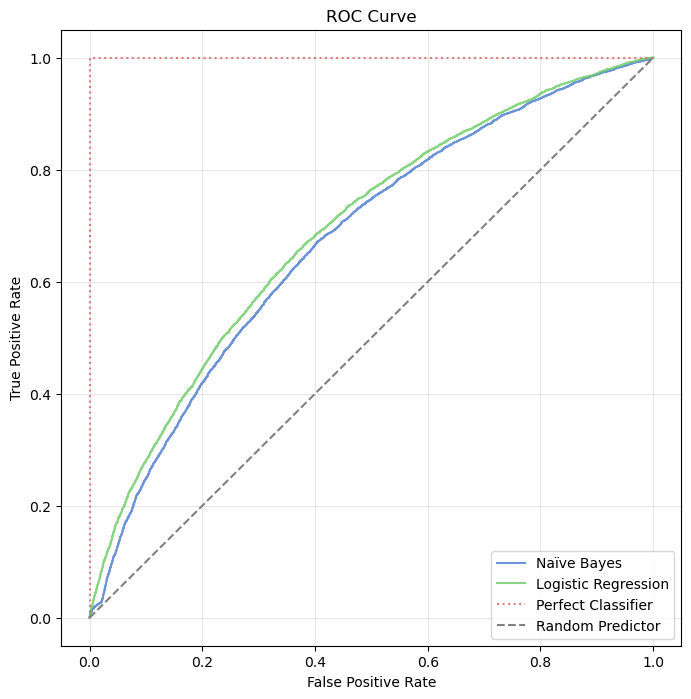

In [22]:
# Plot the ROC curve for the Naïve Bayes classifier and the Logistic regression
fig, ax = plt.subplots(figsize=(8, 8))

# Extract and plot the false positive rate, true positive rate and thresholds
# for the Naïve Bayes classifier and the Logistic regression
fpr, tpr, thresholds = roc_curve(y_test, p_nbc_test)
ax.plot(fpr, tpr, label="Naïve Bayes", alpha=0.8)

fpr, tpr, thresholds = roc_curve(y_test, p_lrc_test)
ax.plot(fpr, tpr, label="Logistic Regression", alpha=0.8)
ax.plot([0, 0, 1], [0, 1, 1], label="Perfect Classifier", linestyle=":", alpha=0.8)

ax.plot([0, 1], [0, 1], color="grey", linestyle="--", label="Random Predictor")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
ax.legend()
ax.grid(alpha=.3)


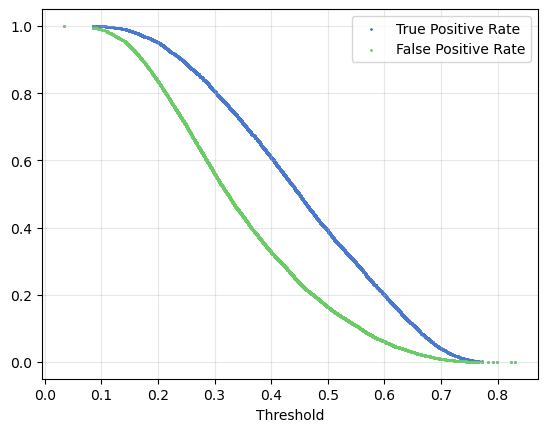

In [23]:
# Also plot how tpr and fpr change with the threshold
fig, ax = plt.subplots()
ax.scatter(thresholds, tpr, label="True Positive Rate", s=1)
ax.set(xlabel="Threshold")
ax.grid(alpha=.3)
ax.scatter(thresholds, fpr, label="False Positive Rate", s=1)
ax.legend()

Note that the TPR is a "good thing" while FPR is a "bad thing". The graph shows us that when we start with a treshold of 1 (i.e. the right-side of the plot) and lower the threshold, we get more of a good thing. But we also pay by getting more of a bad thing. The ROC curve essentially shows this trade-off. 

**For a good model, the price in terms of FPR for getting more TPR is low, for a bad model that price is high.**

Now let's also compute the area under the curve (AUC), which is a single number that reliably characterizes the overall performance of a classifier. In our view, this is a much better single-number summary of the performance than the F1 Score. Also note that the F1 Score is for a particular threshold $\gamma$.

In [24]:
# Compute the AUC score for the Naïve Bayes classifier and the Logistic regression
print("Area Under the ROC Curve (AUC)")
print("-" * 30)
print(f"Naïve Bayes        : {roc_auc_score(y_test, p_nbc_test):.3f}")
print(f"Logistic regression: {roc_auc_score(y_test, p_lrc_test):.3f}")


Area Under the ROC Curve (AUC)
------------------------------
Naïve Bayes        : 0.673
Logistic regression: 0.691


Another and maybe more intuitive way to represent the precision-recall tradeoff is, well, the precision-recall-curve. It is more interpretable as the ROC curve. However, it does not lend itself to the calculation of a single performance measure like AUC. That is where the ROC curve shines.

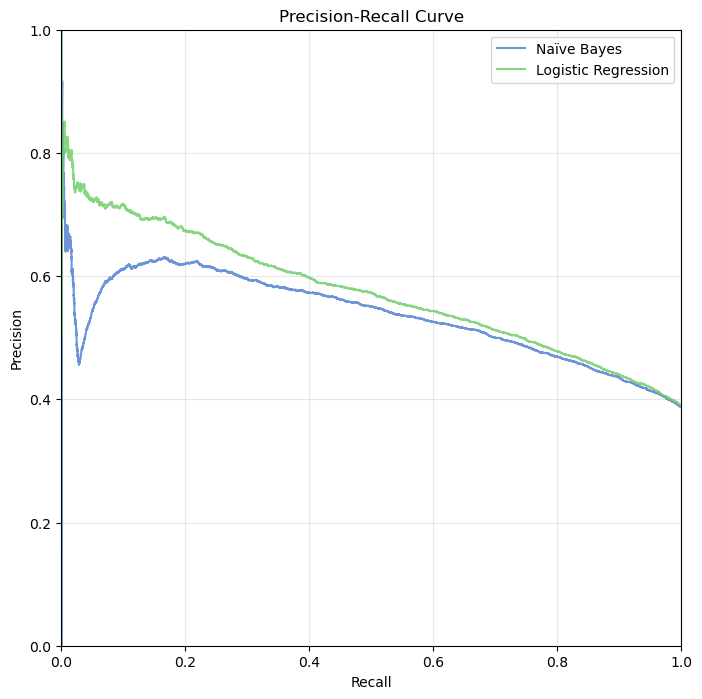

In [25]:
from sklearn.metrics import precision_recall_curve

# Plot the precision-recall curve for the Naïve Bayes classifier and the Logistic regression
fig, ax = plt.subplots(figsize=(8, 8))

# Extract and plot the precision, recall and thresholds
# for the Naïve Bayes classifier and the Logistic regression
precision, recall, thresholds = precision_recall_curve(y_test, p_nbc_test)
ax.plot(recall, precision, label="Naïve Bayes", alpha=0.8)

precision, recall, thresholds = precision_recall_curve(y_test, p_lrc_test)
ax.plot(recall, precision, label="Logistic Regression", alpha=0.8)

ax.set(xlabel="Recall", ylabel="Precision", title="Precision-Recall Curve",
       xlim=(0, 1), ylim=(0, 1))
ax.set_title("Precision-Recall Curve")
ax.legend()
ax.grid(alpha=.3)

#### ➡️ ✏️ Task 2

Isn't it funny that the curves are so "wiggly" at the left end of the graph? They are not even monotonic. Explain why this happens! Why does it particularly happen on the left side?

___


### Confusion Matrix

The confusion matrix is a tool that summarizes the performance of a classification algorithm using the $TP$, $TN$, $FP$, and $FN$ values. It provides a detailed breakdown of predictions into each of these four categories. The confusion matrix is typically used to measure the performance of a binary classifier, but it can also be used for multi-class problems. It contains all the information about the performance of a classifier, but it is more difficult to interpret than some of the other metrics.

Text(0.5, 1.0, 'Logistic Regression')

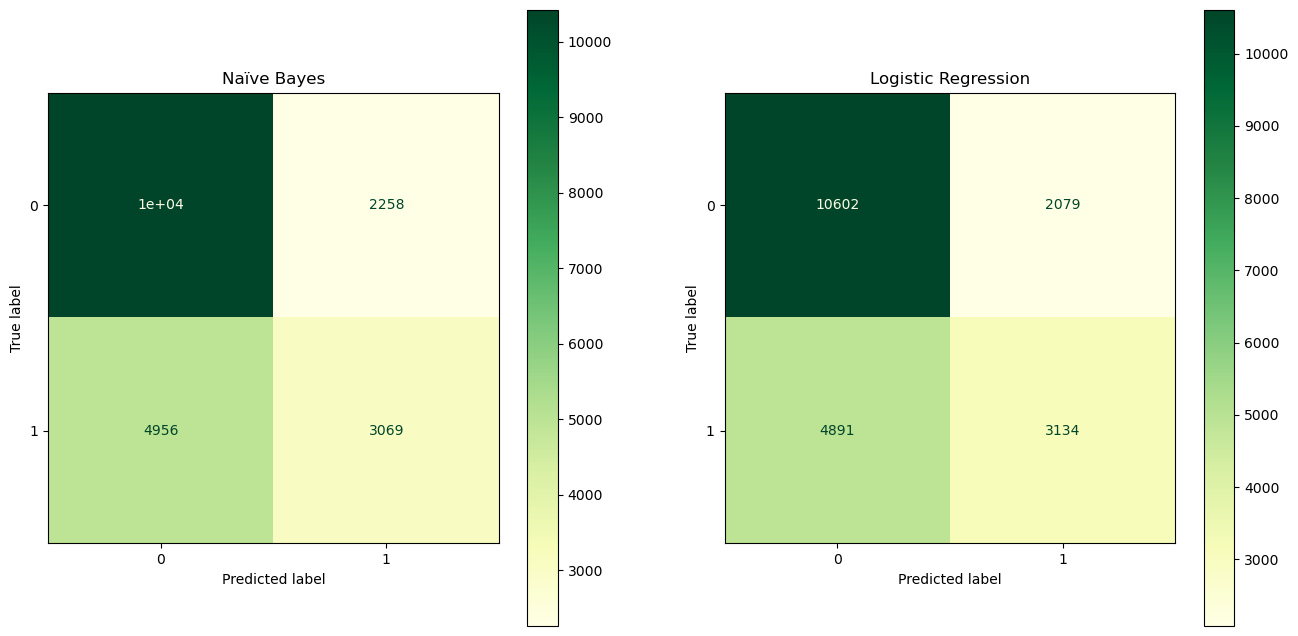

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Compute the confusion matrix for the Naïve Bayes classifier and the Logistic regression
cm_nbc = confusion_matrix(y_test, y_hat_nbc_test)
cm_lrc = confusion_matrix(y_test, y_hat_lrc_test)

# Plot the confusion matrices
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

ConfusionMatrixDisplay.from_estimator(nbc, X_test, y_test, ax=ax[0], cmap=plt.cm.YlGn)
ax[0].set_title("Naïve Bayes")
ConfusionMatrixDisplay.from_estimator(lrc, X_test, y_test, ax=ax[1], cmap=plt.cm.YlGn)
ax[1].set_title("Logistic Regression")

While you may see such confusion matrices relatively often in this form, we do not like one particular detail: the numbers in the four fields are absolut. So they depend on the sample size and are hard to interpret. Below, you see another version that shows the propertion of casses falling into the four fields. Do you see how this conveys more information?

Text(0.5, 1.0, 'Logistic Regression')

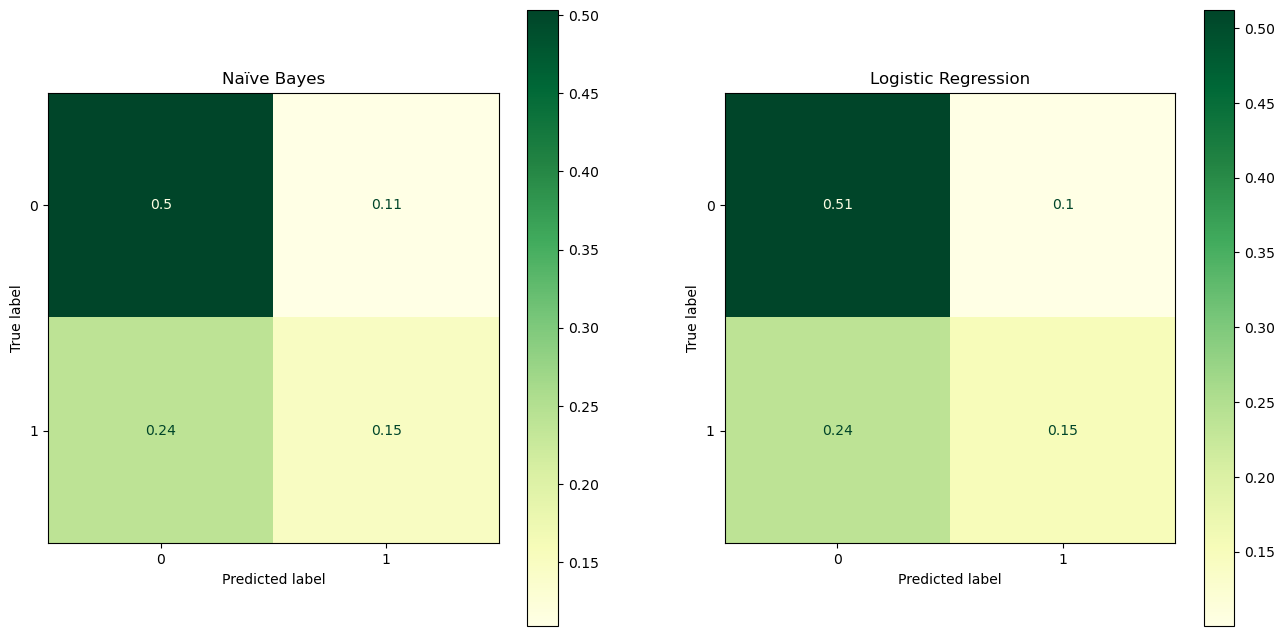

In [27]:


fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# Normalize by total (so cells sum to 1)
ConfusionMatrixDisplay.from_estimator(
    nbc, X_test, y_test,
    normalize='all',      # 'true', 'pred', or 'all'
    cmap=plt.cm.YlGn,
    ax=ax[0]
)
ax[0].set_title("Naïve Bayes")

ConfusionMatrixDisplay.from_estimator(
    lrc, X_test, y_test,
    normalize='all',      # same here
    cmap=plt.cm.YlGn,
    ax=ax[1]
)
ax[1].set_title("Logistic Regression")


#### ➡️ ✏️ Task 3 (Optional)
Fit two new models on `X_train`:
+ A `GaussianNB` model which uses a [`SplineTransformer`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.SplineTransformer.html) first to create features.
+ A `LogisticRegression` model which also uses a `SplineTransformer` first.

For both models, compare the accuracy, precision, recall, and AUC on the test set. Also, plot the ROC curve for both models.

Which models would you use for the task at hand? Discuss with your classmates.

In [28]:
# Your code

from sklearn.preprocessing import SplineTransformer

In [29]:
# SOLUTION: Naïve Bayes

preprocess = ColumnTransformer(
    [("spline", SplineTransformer(n_knots=5, degree=3, include_bias=False), cont_cols)],
    force_int_remainder_cols=False
)

nbc_spline = Pipeline([
    ("prep", preprocess),
    ("clf", GaussianNB())  # clf stands for classifier
]).fit(X_train, y_train)

nbc_spline

y_hat_nbc_spline_test = nbc_spline.predict(X_test)



ac = accuracy_score(y_test, y_hat_nbc_spline_test)
prec = precision_score(y_test, y_hat_nbc_spline_test)
rec = recall_score(y_test, y_hat_nbc_spline_test)
auc = roc_auc_score(y_test, y_hat_nbc_spline_test)

print(f"Accuracy: {ac:.3f}\n")
print(f"Precision: {prec:.3f}\n")
print(f"Recall: {rec:.3f}\n")
print(f"AUC: {auc:.3f}\n")

Accuracy: 0.414

Precision: 0.395

Recall: 0.958

AUC: 0.514



In [30]:
# SOLUTION: Logistic regression

lrc_spline = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression())  # clf stands for classifier
]).fit(X_train, y_train)

nbc_spline

y_hat_lrc_spline_test = lrc_spline.predict(X_test)



ac = accuracy_score(y_test, y_hat_lrc_spline_test)
prec = precision_score(y_test, y_hat_lrc_spline_test)
rec = recall_score(y_test, y_hat_lrc_spline_test)
auc = roc_auc_score(y_test, y_hat_lrc_spline_test)

print(f"Accuracy: {ac:.3f}\n")
print(f"Precision: {prec:.3f}\n")
print(f"Recall: {rec:.3f}\n")
print(f"AUC: {auc:.3f}\n")


Accuracy: 0.663

Precision: 0.599

Recall: 0.396

AUC: 0.614



/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


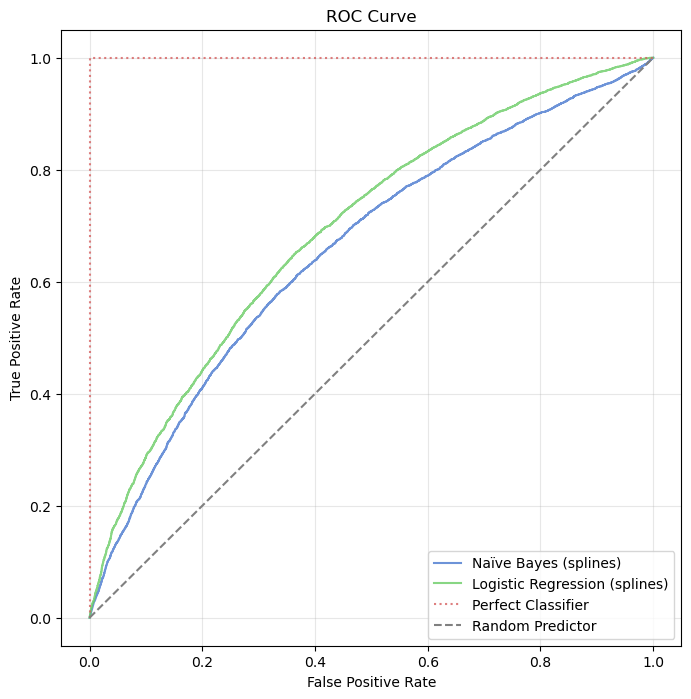

In [31]:
# SOLUTION: ROC Curve

# Get predicted probabilities
p_nbc_spline_test = nbc_spline.predict_proba(X_test)[:, 1]
p_lrc_spline_test = lrc_spline.predict_proba(X_test)[:, 1]


fig, ax = plt.subplots(figsize=(8, 8))

# Extract and plot the false positive rate, true positive rate and thresholds
# for the Naïve Bayes classifier and the Logistic regression
fpr, tpr, thresholds = roc_curve(y_test, p_nbc_spline_test)
ax.plot(fpr, tpr, label="Naïve Bayes (splines)", alpha=0.8)

fpr, tpr, thresholds = roc_curve(y_test, p_lrc_spline_test)
ax.plot(fpr, tpr, label="Logistic Regression (splines)", alpha=0.8)
ax.plot([0, 0, 1], [0, 1, 1], label="Perfect Classifier", linestyle=":", alpha=0.8)

ax.plot([0, 1], [0, 1], color="grey", linestyle="--", label="Random Predictor")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
ax.legend()
ax.grid(alpha=.3)